# L8c Example: Ridge Coefficient Shrinkage

> **Learning objectives**
>
> - Compare OLS and ridge estimates on correlated features.
> - Observe coefficient shrinkage as $\lambda$ increases.
> - Verify that the intercept is not penalized.
> - Avoid interpreting a large coefficient change as automatic model improvement.


## Setup

Run the local setup cell first. It activates the pinned course environment, loads every package used by this meeting, and includes the `Week08Core` module from [`../src/Week08Core.jl`](../src/Week08Core.jl), which provides the functions called below.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes the meeting's local source. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


The setup cell completed, so the environment and this notebook's local source are loaded. The cell below builds two deliberately correlated features in `X::Matrix{Float64}` from the grid `x::Vector{Float64}`, together with the response `y::Vector{Float64}`. It then fits ridge regression at every penalty in `lambdas::Vector{Float64}`, collecting the fits in `fits::Vector{NamedTuple}` and the resulting coefficient path in `coefficient_path::DataFrame`.


In [2]:
x = collect(range(-2.0, 2.0; length = 60))
X = hcat(x, x .+ 0.03 .* sin.(10 .* x))
y = 1.5 .+ 2.0 .* x .+ 0.15 .* cos.(7 .* x)
lambdas = [0.0, 0.1, 1.0, 10.0, 100.0]
fits = [ridge_fit(X, y, lambda) for lambda in lambdas]

coefficient_path = DataFrame(
    lambda = lambdas,
    intercept = [fit.coefficients[1] for fit in fits],
    beta_1 = [fit.coefficients[2] for fit in fits],
    beta_2 = [fit.coefficients[3] for fit in fits],
    coefficient_norm = [norm(fit.coefficients[2:end]) for fit in fits],
)
pretty_table(coefficient_path)


┌─────────┬───────────┬──────────┬─────────────┬──────────────────┐
│  lambda │ intercept │   beta_1 │      beta_2 │ coefficient_norm │
│ Float64 │   Float64 │  Float64 │     Float64 │          Float64 │
├─────────┼───────────┼──────────┼─────────────┼──────────────────┤
│     0.0 │   1.51058 │      2.0 │ 5.44288e-12 │              2.0 │
│     0.1 │   1.51058 │  1.11781 │    0.880907 │           1.4232 │
│     1.0 │   1.51058 │  1.00717 │    0.980728 │          1.40578 │
│    10.0 │   1.51058 │ 0.944256 │    0.941653 │          1.33354 │
│   100.0 │   1.51058 │ 0.623326 │    0.623111 │         0.881364 │
└─────────┴───────────┴──────────┴─────────────┴──────────────────┘


In [3]:
@test coefficient_path.coefficient_norm[end] < coefficient_path.coefficient_norm[1]
@test abs(coefficient_path.intercept[end] - mean(y)) < 0.1
:ridge_shrinkage_verified


:ridge_shrinkage_verified

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 1 for log10 based xscale
└ @ Plots ~/.julia/packages/Plots/GIume/src/utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 1 for log10 based xscale
└ @ Plots ~/.julia/packages/Plots/GIume/src/utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


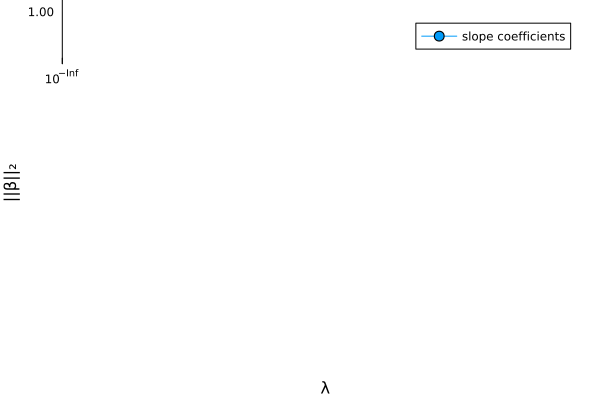

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 1 for log10 based xscale
└ @ Plots ~/.julia/packages/Plots/GIume/src/utils.jl:105


In [4]:
plot(lambdas, coefficient_path.coefficient_norm; xscale = :log10, marker = :circle, xlabel = "λ", ylabel = "||β||₂", label = "slope coefficients")


## Summary

Correlated predictors allow many similar fits with unstable individual coefficients. Ridge selects a smaller-norm solution, but model selection still requires held-out evidence.
